Predicting Obesity Class using K-Means Clustering

About the Project

Data Source: 
The data was obtained from the UC Irvine Machine Learning Repository https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

Citation: 
Estimation of Obesity Levels Based On Eating Habits and Physical Condition  [Dataset]. (2019). UCI Machine Learning Repository. https://doi.org/10.24432/C5H31Z.

Dataset Description: 
This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. The data contains 17 attributes and 2111 records, the records are labeled with the class variable NObesity (Obesity Level), that allows classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III. 77% of the data was generated synthetically using the Weka tool and the SMOTE filter, 23% of the data was collected directly from users through a web platform.

Project Scope: 
This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. For this project, I am intending to using a KMeans Clustering model to predict the Obesity category for individuals with features in the dataset. I provide a screenshot below of the meaning of the features in the data. However, I also do some additional work in the Exploratory data analysis section of this project.

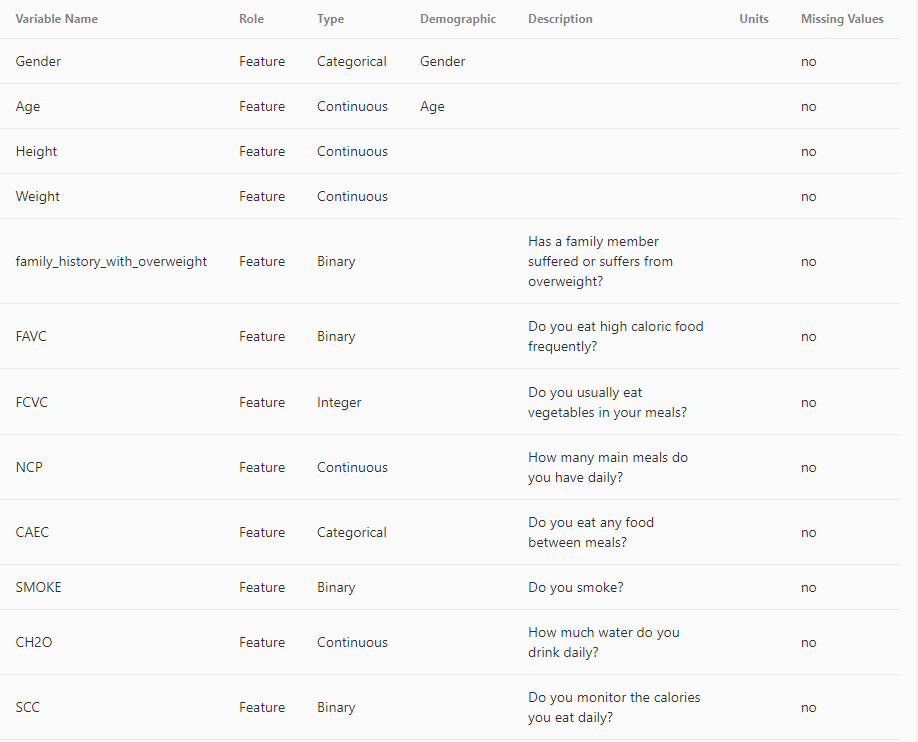

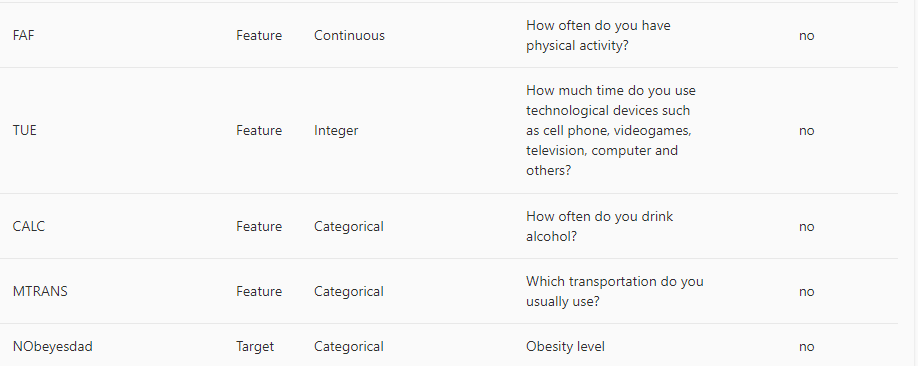

Github Repo - 

Importing Required Libraries

In [7]:
#Loading required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [8]:
#Loading the dataset
df = pd.read_csv(r"ObesityDataSet_raw_and_data_sinthetic.csv")

Exploratory Data Analysis

In [9]:
#Display first few rows of data
print(df.head())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

Data Cleaning
For the data cleaning portion of this project, I performed the following:
- Checked for and addressed null values
- Confirmed the data statistical distribution using data.describe()

In [10]:
#Check for data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [11]:
#Check for missing values
print(df.isnull().sum())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


In [12]:
#Handling missing values (if any)
df.fillna(df.median(numeric_only=True), inplace=True)

In [13]:
#Statistical summary
print(df.describe())

               Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.419043     2.685628   
std       6.345968     0.093305    26.191172     0.533927     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.385502     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000000     1.000000     0.625350  
75% 

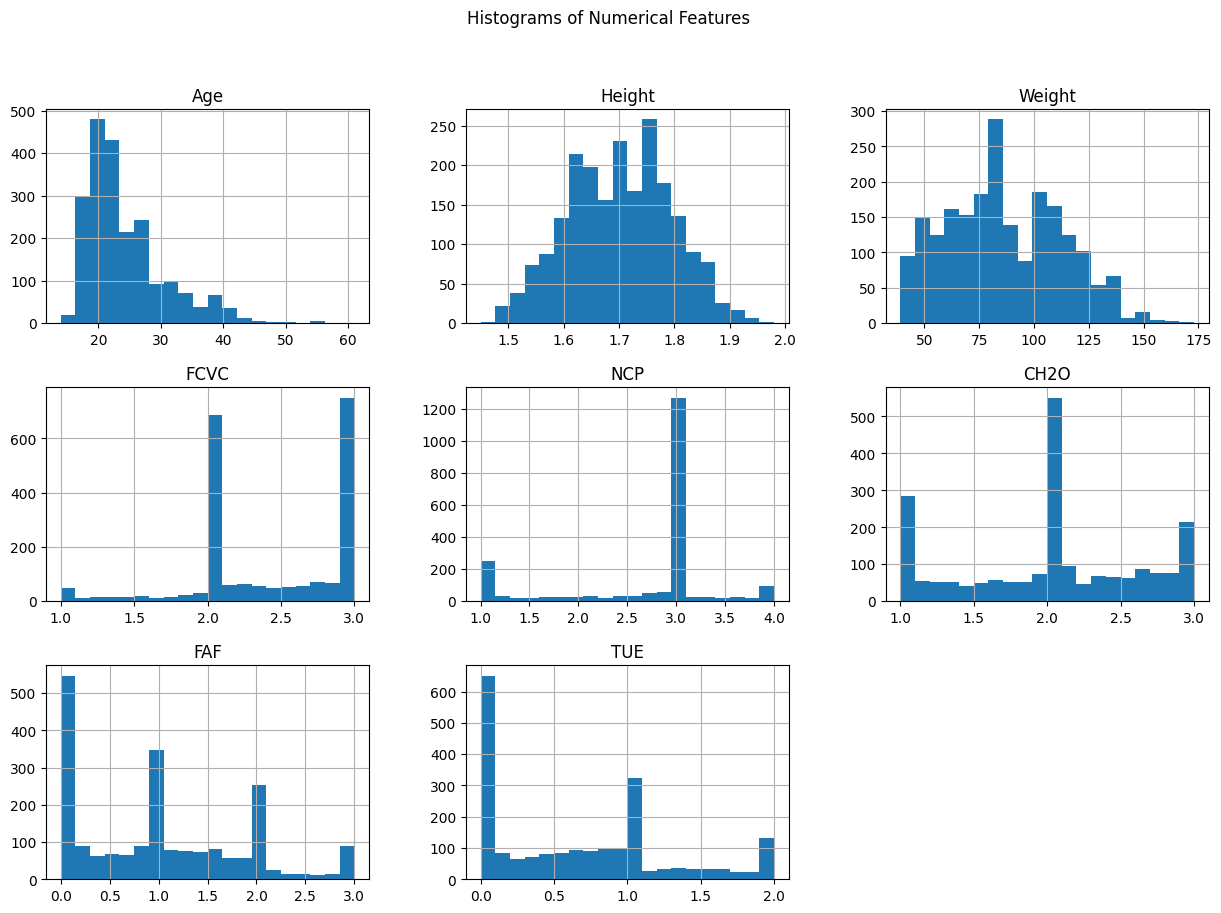

In [14]:
#Showing the distribution of numerical features
num_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[num_features].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features')
plt.show()


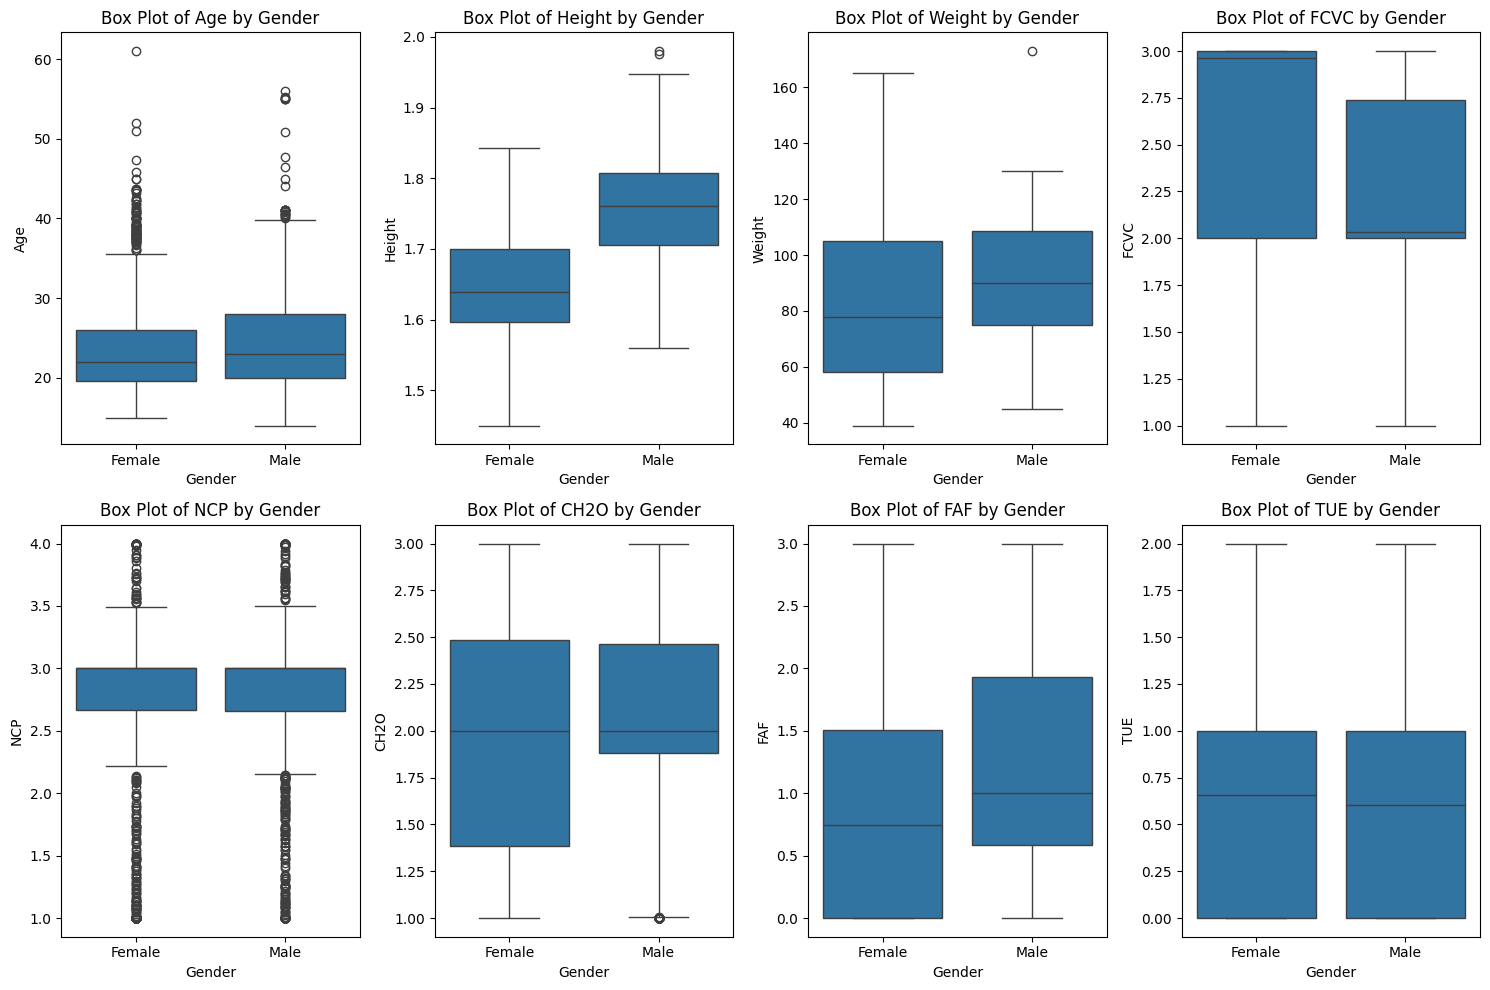

In [15]:
#Comparing distribution of num features, grouped by Gender
plt.figure(figsize=(15, 10))
for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x='Gender', y=feature, data=df)
    plt.title(f'Box Plot of {feature} by Gender')
plt.tight_layout()
plt.show()


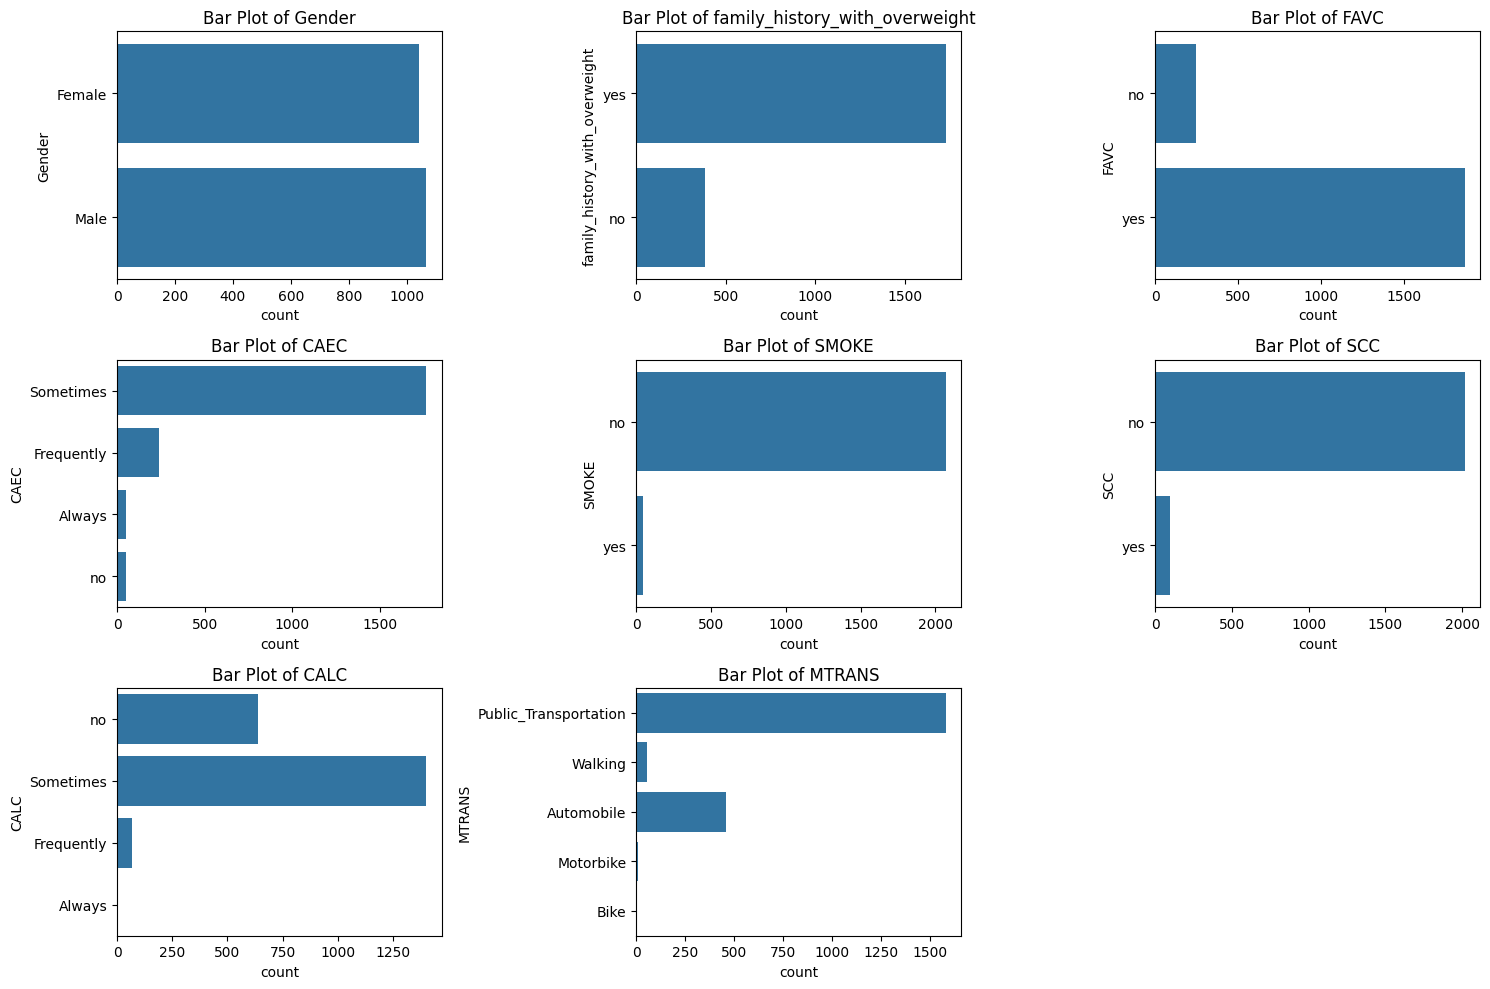

In [16]:
#Showing frequency distribution of Categorical features
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(df[feature])
    plt.title(f'Bar Plot of {feature}')
plt.tight_layout()
plt.show()


Model Building

Methodology

K-means clustering is an unsupervised learning algorithm that partitions data into distinct groups (clusters) based on feature similarity, aiming to minimize the distance between data points and their assigned cluster centroid. To build a K-means model for predicting obesity classes, I applied the following steps:

- Exploratory data analysis (EDA) to explore data distributions, handle categorical encoding, and detect outliers 
- Standardized numerical features to ensure equal contribution to the clustering process
- Used PCA for dimensionality reduction to visualize clusters in a 2D space 
- Determined the optimal number of clusters by applying the Elbow Method
- Trained the K-means model using the selected number of clusters 
- Evaluated its performance using metrics like the silhouette score, and map clusters back to the most common obesity class in each cluster for interpretability

In [17]:
# Encoding categorical features
label_encoders = {}
for col in ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [18]:
print(df.head())

   Gender   Age  Height  Weight  family_history_with_overweight  FAVC  FCVC  \
0       0  21.0    1.62    64.0                               1     0   2.0   
1       0  21.0    1.52    56.0                               1     0   3.0   
2       1  23.0    1.80    77.0                               1     0   2.0   
3       1  27.0    1.80    87.0                               0     0   3.0   
4       1  22.0    1.78    89.8                               0     0   2.0   

   NCP  CAEC  SMOKE  CH2O  SCC  FAF  TUE  CALC  MTRANS           NObeyesdad  
0  3.0     2      0   2.0    0  0.0  1.0     3       3        Normal_Weight  
1  3.0     2      1   3.0    1  3.0  0.0     2       3        Normal_Weight  
2  3.0     2      0   2.0    0  2.0  1.0     1       3        Normal_Weight  
3  3.0     2      0   2.0    0  2.0  0.0     1       4   Overweight_Level_I  
4  1.0     2      0   2.0    0  0.0  0.0     2       3  Overweight_Level_II  


In [19]:
# Encode the target column 'NObeyesdad'
obesity_encoder = LabelEncoder()
df['NObeyesdad_encoded'] = obesity_encoder.fit_transform(df['NObeyesdad'])

In [20]:
# Scaling numerical features
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [21]:
#Dimensionality Reduction using PCA
pca = PCA(n_components=2)
pca_df = pca.fit_transform(df[numerical_features])

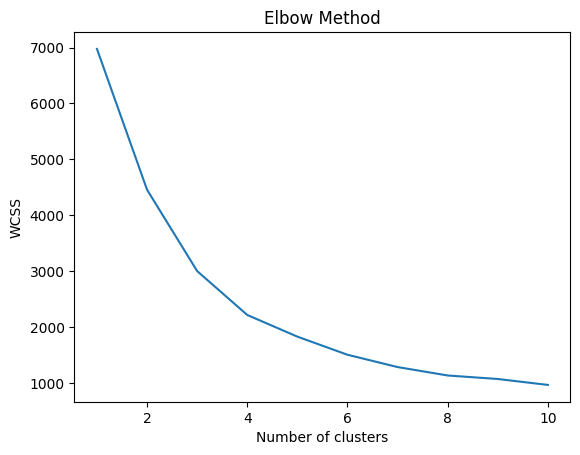

In [22]:
# Choosing the number of clusters using the elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=50)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

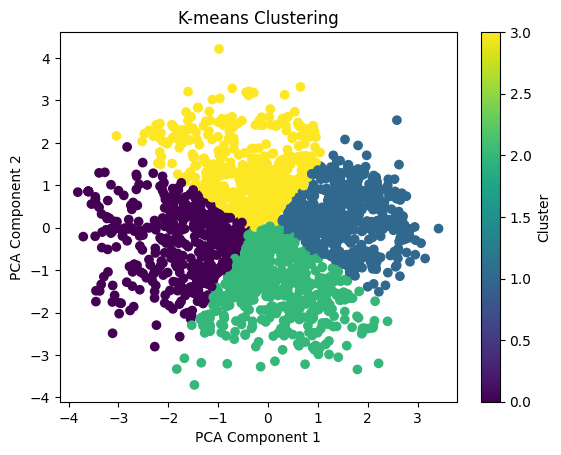

In [23]:
# Choose the optimal number of clusters (e.g., 3 based on the Elbow Method)
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(pca_df)

# Add the cluster labels to the original data
df['Cluster'] = clusters


# Visualize clusters with PCA components
plt.scatter(pca_df[:, 0], pca_df[:, 1], c=clusters, cmap='viridis', marker='o')
plt.title('K-means Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [24]:
# Calculate silhouette score to evaluate the clustering quality
silhouette_avg = silhouette_score(pca_df, clusters)
print(f'Silhouette Score: {silhouette_avg:.2f}')

# Mapping clusters to obesity classes
cluster_mapping = df.groupby('Cluster')['NObeyesdad_encoded'].agg(lambda x: x.mode()[0])
df['Predicted_Obesity_Class'] = df['Cluster'].map(cluster_mapping)

# Decode the predicted obesity class
df['Predicted_Obesity_Class'] = obesity_encoder.inverse_transform(df['Predicted_Obesity_Class'])

# Display the final DataFrame
print(df[['Cluster', 'NObeyesdad', 'Predicted_Obesity_Class']])

Silhouette Score: 0.35
      Cluster           NObeyesdad Predicted_Obesity_Class
0           0        Normal_Weight           Normal_Weight
1           2        Normal_Weight     Insufficient_Weight
2           2        Normal_Weight     Insufficient_Weight
3           1   Overweight_Level_I         Obesity_Type_II
4           3  Overweight_Level_II        Obesity_Type_III
...       ...                  ...                     ...
2106        1     Obesity_Type_III         Obesity_Type_II
2107        1     Obesity_Type_III         Obesity_Type_II
2108        1     Obesity_Type_III         Obesity_Type_II
2109        1     Obesity_Type_III         Obesity_Type_II
2110        1     Obesity_Type_III         Obesity_Type_II

[2111 rows x 3 columns]


In [26]:
# Save the final data to a CSV file
df.to_csv('clustered_obesity_data.csv', index=False)

Conclusion

The K-means clustering approach does a fair job of segmenting individuals based on their characteristics to predict obesity classes, providing valuable insights into patterns associated with different levels of obesity. With a silhouette score of 0.35, the model performance is average and can be improved by getting more quality data, as well as some hyperparameter tuning. 

By using the Elbow Method and silhouette score to determine the optimal number of clusters, the model achieved a balance between cluster compactness and separation, allowing for meaningful interpretation of groupings. 

Overall, the project illustrates the utility of unsupervised learning techniques in healthcare analytics and provides a foundation for further refining clustering models or integrating them with other predictive methods.